# 01 Preprocessing
Use this notebook to validate dataset structure before image preprocessing.

In [1]:
from pathlib import Path

# 1) Expected split/class layout
splits = ["train", "val", "test"]
classes = ["normal", "glaucoma"]
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# 2) Try common locations so this works regardless of notebook working directory
candidates = [
    Path("dataset"),
    Path("../dataset"),
    Path("glaucoma_project/dataset"),
    Path("../glaucoma_project/dataset"),
]

dataset_root = next((p.resolve() for p in candidates if p.exists()), None)

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

if dataset_root is None:
    print("No dataset folder found in expected locations.")
    print("Checked:")
    for p in candidates:
        print(f"  - {p.resolve()}")
    print("\nCreate the folder structure first, then run this cell again.")
else:
    print(f"Dataset root: {dataset_root}")

    total_images = 0
    missing_folders = []

    for split in splits:
        print(f"\n{split.upper()}:")
        for cls in classes:
            cls_path = dataset_root / split / cls
            if not cls_path.exists():
                print(f"  {cls:<9} -> MISSING FOLDER")
                missing_folders.append(str(cls_path))
                continue

            files = [f for f in cls_path.iterdir() if f.is_file()]
            image_files = [f for f in files if f.suffix.lower() in valid_ext]
            non_image_count = len(files) - len(image_files)

            print(
                f"  {cls:<9} -> {len(image_files):>5} images"
                + (f"  ({non_image_count} non-image files ignored)" if non_image_count else "")
            )

            total_images += len(image_files)

    print("\n" + "=" * 60)
    print(f"Total images found: {total_images}")

    if missing_folders:
        print("Status: INCOMPLETE")
        print("Missing folders:")
        for folder in missing_folders:
            print(f"  - {folder}")
    elif total_images == 0:
        print("Status: EMPTY DATASET (folders exist, but no valid images found)")
    else:
        print("Status: OK - dataset structure is valid and non-empty")
    print("=" * 60)

DATASET VERIFICATION
Dataset root: C:\Users\svmoo\OneDrive\Documents\GLUCOMA\glaucoma_project\dataset

TRAIN:
  normal    ->  3936 images
  glaucoma  ->  2366 images

VAL:
  normal    ->   843 images
  glaucoma  ->   507 images

TEST:
  normal    ->   845 images
  glaucoma  ->   508 images

Total images found: 9005
Status: OK - dataset structure is valid and non-empty


## Step 2: Image Preprocessing
This section loads one real fundus image, runs the preprocessing pipeline, and lets you visualize the result before batch processing.

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if (project_root / "src").exists():
    sys.path.append(str(project_root))
else:
    sys.path.append(str(project_root.parent))

from src.preprocessing import preprocess_image, visualize_preprocessing

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


Sample image: ..\dataset\train\normal\normal_000001.png
Original shape: (746, 746, 3)
Green channel shape: (746, 746)
Normalized range: [0.031, 0.800]
Saved to ..\outputs\plots\preprocessing.png


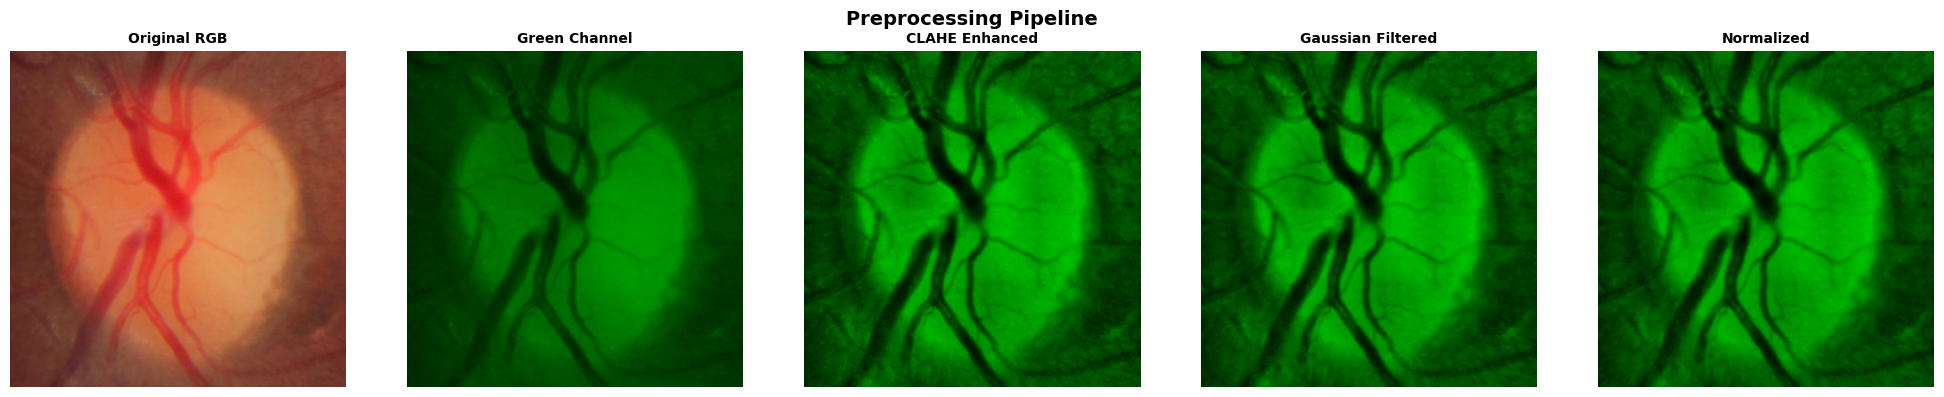

In [3]:
# Pick one real sample image from the dataset
sample_candidates = sorted([p for p in Path("dataset/train/normal").glob("*") if p.suffix.lower() in valid_ext])
if not sample_candidates:
    sample_candidates = sorted([p for p in Path("../dataset/train/normal").glob("*") if p.suffix.lower() in valid_ext])

assert sample_candidates, "No sample images found in dataset/train/normal"

sample_image = sample_candidates[0]
print(f"Sample image: {sample_image}")

results = preprocess_image(str(sample_image), use_clahe=True)
print(f"Original shape: {results['original_rgb'].shape}")
print(f"Green channel shape: {results['green_channel'].shape}")
print(
    f"Normalized range: [{results['normalized'].min():.3f}, {results['normalized'].max():.3f}]"
)

visualize_preprocessing(results, save_path="../outputs/plots/preprocessing.png")

In [1]:
def batch_preprocess_images(input_root, output_root=None, use_clahe=True):
    """Run preprocessing over a folder of images and return a list of results."""
    input_root = Path(input_root)
    valid_ext_local = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    image_paths = sorted([p for p in input_root.rglob("*") if p.is_file() and p.suffix.lower() in valid_ext_local])

    outputs = []
    for image_path in image_paths:
        try:
            result = preprocess_image(str(image_path), use_clahe=use_clahe)
            outputs.append({"path": image_path, "result": result})
            if output_root is not None:
                output_root = Path(output_root)
                output_root.mkdir(parents=True, exist_ok=True)
                save_path = output_root / f"{image_path.stem}_preprocessing.png"
                visualize_preprocessing(result, save_path=str(save_path))
        except Exception as exc:
            print(f"Skipped {image_path.name}: {exc}")

    print(f"Processed {len(outputs)} image(s) from {input_root}")
    return outputs